# Titanic Dataset - Survival Analysis
**Data Science with Python Internship – Task 2**

This notebook explores the Titanic dataset to understand survival patterns based on gender, passenger class, and age. It covers:
1. Loading the dataset
2. Data cleaning (handling missing values)
3. Answering key analysis questions
4. Visualizing survival patterns with Seaborn / Matplotlib


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")
%matplotlib inline


## 1. Load Titanic Dataset

The dataset used here is the classic Titanic dataset (same data made available on Kaggle: https://www.kaggle.com/c/titanic/data), loaded here via Seaborn's bundled copy for reproducibility. If you have downloaded `train.csv` from Kaggle yourself, just replace the loading line below with:

```python
df = pd.read_csv("titanic.csv")
```


In [2]:
# Load dataset (Kaggle-equivalent Titanic data)
df = sns.load_dataset("titanic")

print("Shape:", df.shape)
df.head()


Shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


## 2. Data Cleaning

Let's check for missing values and handle them appropriately.


In [4]:
df.isnull().sum().sort_values(ascending=False)


deck           688
age            177
embarked         2
embark_town      2
sex              0
pclass           0
survived         0
fare             0
parch            0
sibsp            0
class            0
adult_male       0
who              0
alive            0
alone            0
dtype: int64

**Observations:**
- `deck` has a huge number of missing values → we'll drop this column.
- `age` has a meaningful number of missing values → we'll fill with the median age.
- `embarked` / `embark_town` have a couple of missing values → fill with the mode (most common port).

We also drop a few redundant columns (`alive`, `who`, `adult_male`, `class`, `embark_town`) that duplicate information already captured by other columns, to keep the working dataframe clean.


In [5]:
# Work on a copy
titanic = df.copy()

# Drop column with too many missing values
titanic.drop(columns=["deck"], inplace=True)

# Fill missing Age with median age
titanic["age"] = titanic["age"].fillna(titanic["age"].median())

# Fill missing Embarked with the mode
titanic["embarked"] = titanic["embarked"].fillna(titanic["embarked"].mode()[0])
titanic["embark_town"] = titanic["embark_town"].fillna(titanic["embark_town"].mode()[0])

# Drop redundant/duplicate columns
titanic.drop(columns=["who", "adult_male", "class", "alive"], inplace=True)

# Confirm no more missing values in key columns
titanic.isnull().sum()


survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
embark_town    0
alone          0
dtype: int64

In [6]:
# Create an Age Group column for group-based analysis
bins = [0, 12, 18, 35, 60, 100]
labels = ["Child (0-12)", "Teen (13-18)", "Young Adult (19-35)", "Adult (36-60)", "Senior (60+)"]
titanic["age_group"] = pd.cut(titanic["age"], bins=bins, labels=labels)

titanic.head()


,survived,pclass,sex,age,sibsp,parch,fare,embarked,embark_town,alone,age_group
0,0,3,male,22.0,1,0,7.2500,S,Southampton,False,Young Adult (19-35)
1,1,1,female,38.0,1,0,71.2833,C,Cherbourg,False,Adult (36-60)
2,1,3,female,26.0,0,0,7.9250,S,Southampton,True,Young Adult (19-35)
3,1,1,female,35.0,1,0,53.1000,S,Southampton,False,Young Adult (19-35)
4,0,3,male,35.0,0,0,8.0500,S,Southampton,True,Young Adult (19-35)


## 3. Analysis Questions

### Q1: Who survived more — males or females?


In [7]:
survival_by_sex = titanic.groupby("sex")["survived"].agg(["mean", "sum", "count"])
survival_by_sex.columns = ["survival_rate", "num_survived", "total_passengers"]
survival_by_sex["survival_rate"] = (survival_by_sex["survival_rate"] * 100).round(1)
survival_by_sex


,survival_rate,num_survived,total_passengers
sex,,,
female,74.2,233,314
male,18.9,109,577


**Insight:** Females had a dramatically higher survival rate than males (roughly 74% vs 19%), reflecting the "women and children first" evacuation policy.


### Q2: Did passenger class affect survival chances?


In [8]:
survival_by_class = titanic.groupby("pclass")["survived"].agg(["mean", "sum", "count"])
survival_by_class.columns = ["survival_rate", "num_survived", "total_passengers"]
survival_by_class["survival_rate"] = (survival_by_class["survival_rate"] * 100).round(1)
survival_by_class


,survival_rate,num_survived,total_passengers
pclass,,,
1,63.0,136,216
2,47.3,87,184
3,24.2,119,491


**Insight:** Passenger class had a strong effect on survival — 1st class passengers survived at the highest rate (~63%), followed by 2nd class (~47%), while 3rd class passengers had the lowest survival rate (~24%). This likely reflects cabin location, proximity to lifeboats, and priority during evacuation.


### Q3: What was the survival rate by age group?


In [9]:
survival_by_age = titanic.groupby("age_group", observed=True)["survived"].agg(["mean", "sum", "count"])
survival_by_age.columns = ["survival_rate", "num_survived", "total_passengers"]
survival_by_age["survival_rate"] = (survival_by_age["survival_rate"] * 100).round(1)
survival_by_age


,survival_rate,num_survived,total_passengers
age_group,,,
Child (0-12),58.0,40,69
Teen (13-18),42.9,30,70
Young Adult (19-35),35.3,189,535
Adult (36-60),40.0,78,195
Senior (60+),22.7,5,22


**Insight:** Children (0-12) had the highest survival rate among age groups, again consistent with priority evacuation for children. Survival rate generally trends downward for older age groups.


### Bonus: Combined effect of gender and class


In [10]:
pivot = titanic.pivot_table(index="pclass", columns="sex", values="survived", aggfunc="mean").round(2) * 100
pivot


sex,female,male
pclass,,
1,97.0,37.0
2,92.0,16.0
3,50.0,14.0


**Insight:** Female passengers in 1st and 2nd class survived at extremely high rates (over 90%), while males in 3rd class had the lowest survival rate of any group.


## 4. Visualizations


### Bar Chart: Survival by Gender


/tmp/ipykernel_584/263189380.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="sex", y="survived", data=titanic, palette="Set2", errorbar=None)


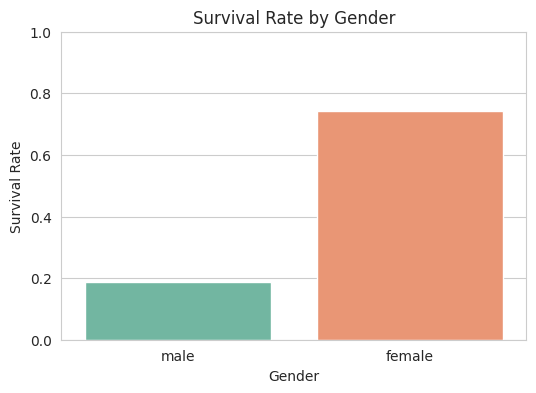

In [11]:
plt.figure(figsize=(6, 4))
sns.barplot(x="sex", y="survived", data=titanic, palette="Set2", errorbar=None)
plt.title("Survival Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.show()


### Bar Chart: Survival by Passenger Class


/tmp/ipykernel_584/1017021382.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="pclass", y="survived", data=titanic, palette="Set2", errorbar=None)


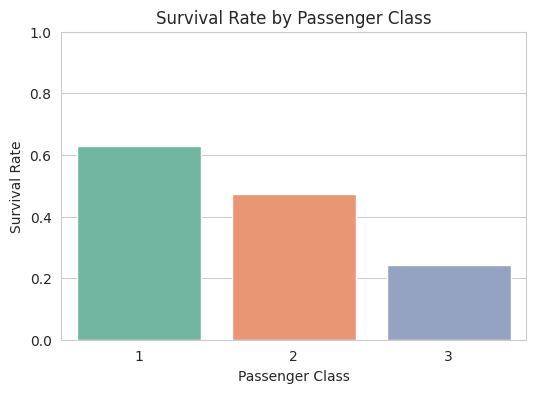

In [12]:
plt.figure(figsize=(6, 4))
sns.barplot(x="pclass", y="survived", data=titanic, palette="Set2", errorbar=None)
plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.show()


### Histogram: Passenger Ages


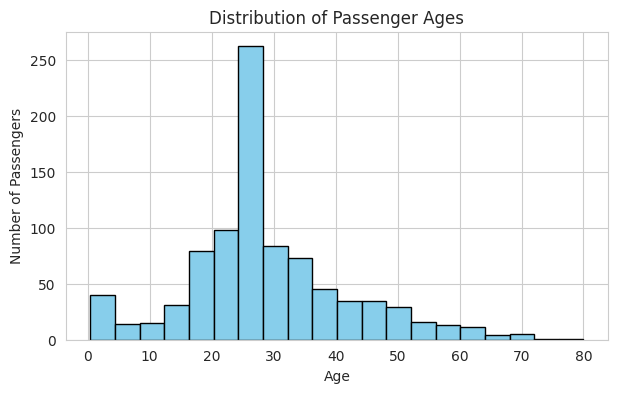

In [13]:
plt.figure(figsize=(7, 4))
titanic["age"].plot(kind="hist", bins=20, color="skyblue", edgecolor="black")
plt.title("Distribution of Passenger Ages")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()


### Bonus Visualization: Survival Rate by Gender and Class


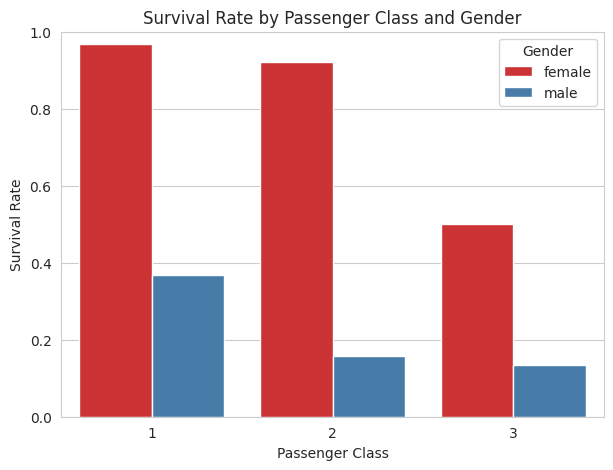

In [14]:
plt.figure(figsize=(7, 5))
sns.barplot(x="pclass", y="survived", hue="sex", data=titanic, palette="Set1", errorbar=None)
plt.title("Survival Rate by Passenger Class and Gender")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.legend(title="Gender")
plt.show()


## Summary of Insights

- **Gender:** Females survived at a much higher rate (~74%) than males (~19%) — the "women and children first" protocol clearly shows in the data.
- **Passenger Class:** Survival rate decreases as class number increases: 1st class (~63%) > 2nd class (~47%) > 3rd class (~24%), highlighting the impact of socio-economic status on survival.
- **Age:** Children had the highest survival rate; survival generally declined with age.
- **Combined effect:** The best odds of survival belonged to women in 1st/2nd class (over 90%), while the worst odds belonged to men in 3rd class.
